Loading data for the Late Fusion Degradation Curve...
Running noise injection sweep across all subjects...


Noise Level 2.0 std: 100%|██████████| 15/15 [00:02<00:00,  6.34it/s]



--- DEGRADATION RESULTS ---
 Noise_Level  F1_Score
         0.0  0.907383
         0.5  0.891986
         1.0  0.849206
         1.5  0.822702
         2.0  0.794945


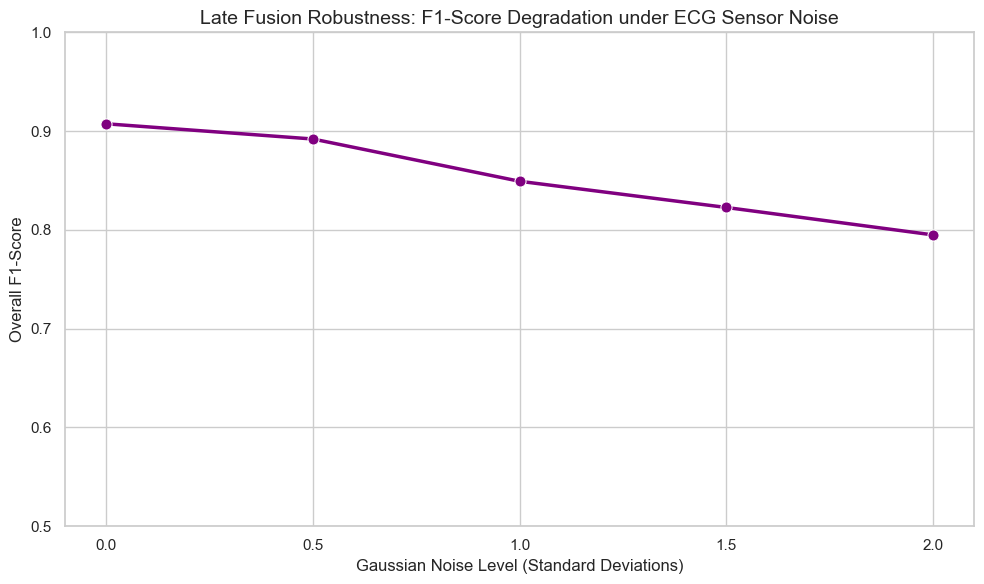


Plot saved successfully as 'thesis_late_fusion_robustness_curve.png'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# --- 1. DATA PREPARATION ---
print("Loading data for the Late Fusion Degradation Curve...")
df = pd.read_csv('wesad_final_normalized_features.csv')

ecg_cols = [c for c in df.columns if 'HRV' in c or 'ECG_Rate' in c]
gsr_cols = [c for c in df.columns if 'SCR' in c or 'EDA' in c]

df['label_idx'] = df['label'].map({1: 0, 2: 1})
df = df[df['label_idx'].notnull()] 

subjects = df['subject_id'].unique()

noise_levels = [0.0, 0.5, 1.0, 1.5, 2.0]
robustness_results = []

print("Running noise injection sweep across all subjects...")

# --- 2. OUTER LOOP: ESCALATING NOISE LEVELS ---
for noise in noise_levels:
    all_actual = []
    all_preds = []
    
    # --- 3. INNER LOOP: LOSO VALIDATION ---
    for test_sub in tqdm(subjects, desc=f"Noise Level {noise} std"):
        train_df = df[df['subject_id'] != test_sub]
        test_df = df[df['subject_id'] == test_sub].copy()
        
        y_train = train_df['label_idx']
        y_test = test_df['label_idx']
        
        # Train experts on perfectly clean laboratory data
        model_ecg = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')
        model_gsr = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')
        
        model_ecg.fit(train_df[ecg_cols], y_train)
        model_gsr.fit(train_df[gsr_cols], y_train)
        
        # Inject noise ONLY into the ECG testing features
        if noise > 0:
            for col in ecg_cols:
                random_noise = np.random.normal(0, noise, test_df[col].shape)
                test_df[col] = test_df[col] + random_noise
        
        # Late Fusion 50/50 Predictions
        prob_ecg_noisy = model_ecg.predict_proba(test_df[ecg_cols])[:, 1]
        prob_gsr_clean = model_gsr.predict_proba(test_df[gsr_cols])[:, 1]
        
        prob_fusion = (prob_ecg_noisy + prob_gsr_clean) / 2.0
        preds_fusion = (prob_fusion >= 0.5).astype(int)
        
        all_actual.extend(y_test.tolist())
        all_preds.extend(preds_fusion.tolist())
        
    # Calculate global F1 for this specific noise level
    level_f1 = f1_score(all_actual, all_preds)
    robustness_results.append({'Noise_Level': noise, 'F1_Score': level_f1})

# --- 4. RESULTS AND PLOTTING ---
results_df = pd.DataFrame(robustness_results)
print("\n--- DEGRADATION RESULTS ---")
print(results_df.to_string(index=False))

# Generate the line plot to match the Early Fusion visual style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
# Using purple to visually distinguish this from the Early Fusion line in your thesis
sns.lineplot(data=results_df, x='Noise_Level', y='F1_Score', marker='o', color='purple', linewidth=2.5, markersize=8)

plt.title('Late Fusion Robustness: F1-Score Degradation under ECG Sensor Noise', fontsize=14)
plt.xlabel('Gaussian Noise Level (Standard Deviations)', fontsize=12)
plt.ylabel('Overall F1-Score', fontsize=12)
plt.ylim(0.5, 1.0)
plt.xticks(noise_levels)
plt.tight_layout()

plt.savefig('thesis_late_fusion_robustness_curve.png', dpi=300)
plt.show()

print("\nPlot saved successfully as 'thesis_late_fusion_robustness_curve.png'.")